# Material Classifier Back-Test — RF v4 vs CNN-PID v2

**Date:** 2026-05-13  
**Source code:** `Code Store/backtest_material_classifiers.ipynb`

Loads the two deployed material classifiers and runs them against **every labelled raw per-packet CSV in `data_logs/datasets/`** (top level; `bin/` and `probe/` skipped). Plots confusion matrices and compares per-class F1.

**Caveat — this is in-sample.** Both models were trained on the same data. Numbers will exceed the 5-fold CV numbers in CLAUDE.md §1 because nothing is held out. The purpose is *not* to claim a new accuracy number; it is to:
1. Visually confirm both models behave as documented.
2. Identify trials where the two models *disagree* — useful for choosing fallback strategy.
3. Provide a side-by-side per-trial prediction table for ad-hoc inspection.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import load_model

BASE = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
# When run from VS Code Jupyter, __file__ may not be defined; fall back to project root.
if not os.path.exists(os.path.join(BASE, 'CLAUDE.md')):
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE, 'data_logs', 'datasets')
MODEL_DIR = os.path.join(BASE, 'Model')
print('Project root:', BASE)
print('Data  :', DATA_DIR)
print('Models:', MODEL_DIR)

Project root: C:\Users\charm\OneDrive\documents\Arduino\PIDpwm
Data  : C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\data_logs\datasets
Models: C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Model


In [2]:
# Constants mirror the trainer source so the back-test extracts windows identically.
LABEL_MAP        = {'hard': 'Hard', 'medium': 'Medium', 'soft': 'Soft'}
RF_FEATURES      = ['delta_pos_max', 'res_drop_pct', 'f_peak', 'rise_ms', 'stiffness_proxy']
CNN_FEATURES     = ['shifted_cond', 'delta_pos', 'd_cond_dt', 'd_dpos_dt', 'res_norm']
WINDOW_LEN       = 40
BIN_MS           = 50
REQUIRED_COLS    = {'loop_index', 'is_press', 'resistance', 'pos_deg', 'pred_force_n',
                    't_ms', 'material', 'shifted_cond'}
MIN_F_PEAK_N             = 1.5
MIN_BASELINE_KOHM        = 1000.0
LOW_BASELINE_F_THRESHOLD = 5.0
CLASSES = ['Hard', 'Medium', 'Soft']

In [3]:
def discover_sources(data_dir):
    out = []
    for fn in sorted(os.listdir(data_dir)):
        full = os.path.join(data_dir, fn)
        if not os.path.isfile(full) or not fn.lower().endswith('.csv'):
            continue
        try:
            head = pd.read_csv(full, nrows=5)
        except Exception as e:
            print(f'  [skip] {fn:40s}  unreadable ({e})')
            continue
        if not REQUIRED_COLS.issubset(head.columns):
            print(f'  [skip] {fn:40s}  schema mismatch')
            continue
        mats  = [m for m in head['material'].dropna().astype(str).str.lower().unique() if m]
        label = LABEL_MAP.get(mats[0]) if mats else None
        if label is None:
            print(f'  [skip] {fn:40s}  no material label')
            continue
        print(f'  [keep] {fn:40s}  -> {label}')
        out.append((label, fn))
    return out

sources = discover_sources(DATA_DIR)
print(f'\n{len(sources)} CSV(s) accepted.')

  [keep] Hard (1).csv                              -> Hard
  [keep] Medium (1).csv                            -> Medium
  [keep] NewModel (1).csv                          -> Soft
  [keep] NewModel (4).csv                          -> Medium
  [skip] NewModel (6).csv                          no material label
  [keep] Soft (3).csv                              -> Soft
  [keep] phase1_20260512_150309.csv                -> Soft
  [keep] phase1_20260512_150425.csv                -> Hard
  [keep] phase1_20260512_151658.csv                -> Medium
  [keep] phase1_20260513_150041.csv                -> Soft
  [keep] phase1_20260513_150318.csv                -> Medium
  [keep] phase1_20260513_151134.csv                -> Hard

11 CSV(s) accepted.


In [4]:
def extract_rf_features(trial_df):
    """5 scalar RF features per trial. Returns (dict, None) or (None, reason)."""
    g = trial_df.reset_index(drop=True)
    if len(g) < 30:
        return None, 'n<30'
    pre  = g[g['is_press'] == 0]
    post = g[g['is_press'] == 1]
    if len(pre) < 5 or len(post) < 5:
        return None, 'no contact window'
    baseline_res_k = float(pre['resistance'].median()) / 1000.0
    min_res_k      = float(post['resistance'].min()) / 1000.0
    res_drop_pct   = (baseline_res_k - min_res_k) / max(baseline_res_k, 1e-6)
    pos_at_contact = float(post['pos_deg'].iloc[0])
    delta_pos_max  = abs(float(post['pos_deg'].min()) - pos_at_contact)
    f_peak         = float(post['pred_force_n'].max())
    if f_peak < MIN_F_PEAK_N:
        return None, f'f_peak={f_peak:.2f}<{MIN_F_PEAK_N}'
    if baseline_res_k < MIN_BASELINE_KOHM and f_peak < LOW_BASELINE_F_THRESHOLD:
        return None, f'baseline={baseline_res_k:.0f}+lowF'
    if f_peak > 0.1:
        t_contact = float(post['t_ms'].iloc[0])
        target    = 0.9 * f_peak
        reached   = post[post['pred_force_n'] >= target]
        rise_ms   = float(reached['t_ms'].iloc[0] - t_contact) if len(reached) else 0.0
    else:
        rise_ms = 0.0
    stiffness_proxy = (f_peak / rise_ms) if rise_ms > 0 else 0.0
    return {
        'delta_pos_max':   delta_pos_max,
        'res_drop_pct':    res_drop_pct,
        'f_peak':          f_peak,
        'rise_ms':         rise_ms,
        'stiffness_proxy': stiffness_proxy,
        'baseline_res_k':  baseline_res_k,
    }, None

In [5]:
def extract_cnn_window(trial_df, baseline_res_k):
    """(40, 5) post-contact window with bin-skip fix. Returns (ndarray, None) or (None, reason)."""
    g = trial_df.reset_index(drop=True)
    post = g[g['is_press'] == 1].reset_index(drop=True)
    if len(post) < 5:
        return None, 'no contact'
    t0             = float(post['t_ms'].iloc[0])
    pos_at_contact = float(post['pos_deg'].iloc[0])
    rel            = post['t_ms'].astype(float).values - t0
    bin_id         = (rel // BIN_MS).astype(int)
    post           = post.assign(_bin=bin_id)
    rows      = []
    prev_cond = None
    prev_dpos = None
    for bid, grp in post.groupby('_bin'):
        if len(rows) >= WINDOW_LEN:
            break
        mean_cond = float(grp['shifted_cond'].mean())
        mean_pos  = float(grp['pos_deg'].mean())
        mean_res  = float(grp['resistance'].mean()) / 1000.0
        delta_pos = mean_pos - pos_at_contact
        d_cond_dt = (mean_cond - prev_cond) / (BIN_MS / 1000.0) if prev_cond is not None else 0.0
        d_dpos_dt = (delta_pos - prev_dpos) / (BIN_MS / 1000.0) if prev_dpos is not None else 0.0
        res_norm  = float(np.clip(mean_res / max(baseline_res_k, 1e-6), 0.0, 1.5))
        rows.append([mean_cond, delta_pos, d_cond_dt, d_dpos_dt, res_norm])
        prev_cond = mean_cond
        prev_dpos = delta_pos
    if len(rows) < WINDOW_LEN:
        return None, f'only {len(rows)} bins'
    return np.array(rows, dtype=np.float32), None

In [6]:
# Walk every accepted CSV, build per-trial RF features + CNN windows, track which trials each model can score.
rf_rows, cnn_windows, info_rows = [], [], []
drops = {'rf': 0, 'cnn': 0}
for label, fn in sources:
    df = pd.read_csv(os.path.join(DATA_DIR, fn))
    for li, g in df.groupby('loop_index'):
        rf_feats, rf_reason = extract_rf_features(g)
        if rf_feats is None:
            drops['rf'] += 1
            cnn_win, cnn_reason = None, 'rf-filter-applied'
        else:
            cnn_win, cnn_reason = extract_cnn_window(g, rf_feats['baseline_res_k'])
            if cnn_win is None:
                drops['cnn'] += 1
        if rf_feats is not None:
            rf_rows.append({**{k: rf_feats[k] for k in RF_FEATURES}, 'label': label,
                            'source': fn, 'loop': int(li)})
            cnn_windows.append(cnn_win)   # may be None
            info_rows.append({'label': label, 'source': fn, 'loop': int(li),
                              'rf_ok': True, 'cnn_ok': cnn_win is not None,
                              'rf_reason': '', 'cnn_reason': cnn_reason or ''})
        else:
            info_rows.append({'label': label, 'source': fn, 'loop': int(li),
                              'rf_ok': False, 'cnn_ok': False,
                              'rf_reason': rf_reason, 'cnn_reason': 'rf-filter-applied'})

info_df = pd.DataFrame(info_rows)
print(f'Trials surfaced (any):        {len(info_df)}')
print(f"Trials RF-scoreable:          {info_df['rf_ok'].sum()}")
print(f"Trials CNN-scoreable:         {info_df['cnn_ok'].sum()}")
print(f"  RF drops (quality filter):  {drops['rf']}")
print(f"  CNN drops (<40 bins, etc.): {drops['cnn']}")
print('\nPer-class counts:')
print(info_df.groupby('label')[['rf_ok','cnn_ok']].sum())

Trials surfaced (any):        286
Trials RF-scoreable:          260
Trials CNN-scoreable:         260
  RF drops (quality filter):  26
  CNN drops (<40 bins, etc.): 0

Per-class counts:
        rf_ok  cnn_ok
label                
Hard       79      79
Medium    112     112
Soft       69      69


In [7]:
rf_model   = joblib.load(os.path.join(MODEL_DIR, 'material_rf.pkl'))
rf_scaler  = joblib.load(os.path.join(MODEL_DIR, 'scaler_mat_rf.pkl'))
cnn_model  = load_model(os.path.join(MODEL_DIR, 'material_cnn_pid.keras'))
cnn_bundle = joblib.load(os.path.join(MODEL_DIR, 'scaler_mat_cnn_pid.pkl'))
cnn_scaler = cnn_bundle['scaler']
cnn_classes = list(cnn_bundle['classes'])
rf_classes  = list(rf_model.classes_)
print('RF classes : ', rf_classes)
print('CNN classes:', cnn_classes)

RF classes :  ['Hard', 'Medium', 'Soft']
CNN classes: ['Hard', 'Medium', 'Soft']


In [8]:
# RF predictions
rf_df  = pd.DataFrame(rf_rows)
X_rf   = rf_df[RF_FEATURES].fillna(0.0).values.astype(np.float32)
Xs_rf  = rf_scaler.transform(X_rf)
rf_pred  = rf_model.predict(Xs_rf)
rf_proba = rf_model.predict_proba(Xs_rf)

# CNN predictions — only on trials with a non-None window
cnn_pred  = np.array([None] * len(rf_rows), dtype=object)
cnn_proba = np.full((len(rf_rows), len(cnn_classes)), np.nan)
valid_idx = [i for i, w in enumerate(cnn_windows) if w is not None]
if valid_idx:
    X_cnn      = np.stack([cnn_windows[i] for i in valid_idx], axis=0)
    flat       = X_cnn.reshape(-1, X_cnn.shape[-1])
    Xs_cnn     = cnn_scaler.transform(flat).reshape(X_cnn.shape).astype(np.float32)
    probs      = np.array(cnn_model.predict(Xs_cnn, verbose=0))
    idx_winner = probs.argmax(axis=1)
    for j, i in enumerate(valid_idx):
        cnn_pred[i]  = cnn_classes[idx_winner[j]]
        cnn_proba[i] = probs[j]

rf_df['rf_pred']  = rf_pred
rf_df['cnn_pred'] = cnn_pred
for j, c in enumerate(rf_classes):
    rf_df[f'rf_prob_{c}'] = rf_proba[:, j]
for j, c in enumerate(cnn_classes):
    rf_df[f'cnn_prob_{c}'] = cnn_proba[:, j]

print(rf_df[['label','rf_pred','cnn_pred']].head(10))
print(f'\nRows: {len(rf_df)}  (RF-scored: all, CNN-scored: {len(valid_idx)})')

  label rf_pred cnn_pred
0  Hard    Hard     Hard
1  Hard    Hard     Hard
2  Hard    Hard     Hard
3  Hard    Hard     Hard
4  Hard    Hard     Hard
5  Hard    Hard     Hard
6  Hard    Hard     Hard
7  Hard    Hard     Hard
8  Hard    Hard     Hard
9  Hard    Hard     Hard

Rows: 260  (RF-scored: all, CNN-scored: 260)


In [9]:
def metric_block(name, y_true, y_pred, labels):
    print(f'==== {name} ====  (n={len(y_true)})')
    acc = (y_true == y_pred).mean()
    print(f'Accuracy (in-sample): {acc:.3f}')
    print(classification_report(y_true, y_pred, labels=labels, target_names=labels,
                                digits=3, zero_division=0))

y_true = rf_df['label'].values
metric_block('RF v4 (in-sample)', y_true, rf_df['rf_pred'].values, CLASSES)

mask_cnn = rf_df['cnn_pred'].notna()
metric_block('CNN-PID v2 (in-sample, CNN-scoreable trials only)',
             rf_df.loc[mask_cnn, 'label'].values,
             rf_df.loc[mask_cnn, 'cnn_pred'].values, CLASSES)

==== RF v4 (in-sample) ====  (n=260)
Accuracy (in-sample): 0.954
              precision    recall  f1-score   support

        Hard      0.975     1.000     0.988        79
      Medium      1.000     0.902     0.948       112
        Soft      0.872     0.986     0.925        69

    accuracy                          0.954       260
   macro avg      0.949     0.962     0.954       260
weighted avg      0.958     0.954     0.954       260

==== CNN-PID v2 (in-sample, CNN-scoreable trials only) ====  (n=260)
Accuracy (in-sample): 0.996
              precision    recall  f1-score   support

        Hard      1.000     1.000     1.000        79
      Medium      1.000     0.991     0.996       112
        Soft      0.986     1.000     0.993        69

    accuracy                          0.996       260
   macro avg      0.995     0.997     0.996       260
weighted avg      0.996     0.996     0.996       260



## Confusion matrices

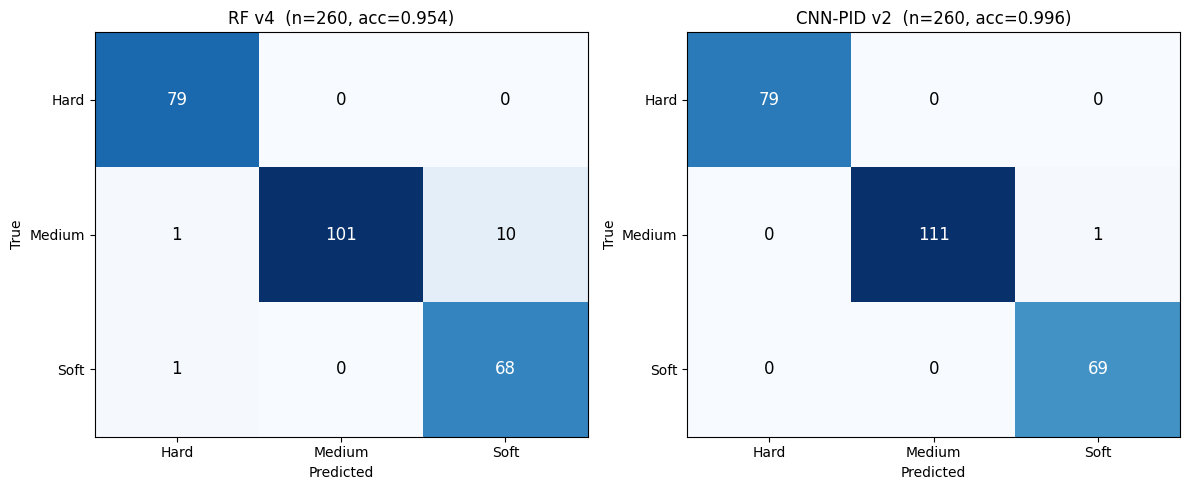

In [10]:
def plot_cm(ax, y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    vmax = cm.max() if cm.max() > 0 else 1
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > vmax * 0.5 else 'black', fontsize=12)
    return cm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_rf  = plot_cm(axes[0], y_true, rf_df['rf_pred'].values, CLASSES,
                 f"RF v4  (n={len(y_true)}, acc={(y_true==rf_df['rf_pred'].values).mean():.3f})")
cm_cnn = plot_cm(axes[1],
                 rf_df.loc[mask_cnn, 'label'].values,
                 rf_df.loc[mask_cnn, 'cnn_pred'].values, CLASSES,
                 f"CNN-PID v2  (n={mask_cnn.sum()}, acc={(rf_df.loc[mask_cnn,'label'].values==rf_df.loc[mask_cnn,'cnn_pred'].values).mean():.3f})")
plt.tight_layout()
plt.show()

## Per-class F1 comparison

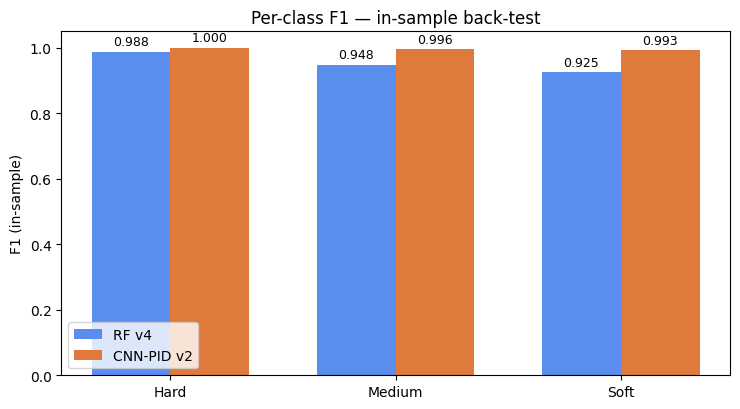

Macro F1:
  RF v4      : 0.954
  CNN-PID v2 : 0.996


In [11]:
rf_f1  = f1_score(y_true, rf_df['rf_pred'].values, labels=CLASSES, average=None, zero_division=0)
cnn_f1 = f1_score(rf_df.loc[mask_cnn, 'label'].values,
                  rf_df.loc[mask_cnn, 'cnn_pred'].values,
                  labels=CLASSES, average=None, zero_division=0)

x = np.arange(len(CLASSES))
w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.2))
b1 = ax.bar(x - w/2, rf_f1,  w, label='RF v4',      color='#5b8def')
b2 = ax.bar(x + w/2, cnn_f1, w, label='CNN-PID v2', color='#e07a3c')
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel('F1 (in-sample)'); ax.set_ylim(0, 1.05)
ax.set_title('Per-class F1 — in-sample back-test')
for b in (b1, b2):
    for r in b:
        ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.02,
                f'{r.get_height():.3f}', ha='center', fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()

print('Macro F1:')
print(f"  RF v4      : {rf_f1.mean():.3f}")
print(f"  CNN-PID v2 : {cnn_f1.mean():.3f}")

## Per-trial disagreement analysis

Trials where one classifier is correct and the other is wrong. Useful for fallback design — if one model has a class blind-spot the other can cover, ensembling helps; otherwise both miss together and the residual error is in the signal, not the model.

In [12]:
scored = rf_df[rf_df['cnn_pred'].notna()].copy()
scored['rf_correct']  = (scored['rf_pred']  == scored['label'])
scored['cnn_correct'] = (scored['cnn_pred'] == scored['label'])
agree    = scored[scored['rf_pred'] == scored['cnn_pred']]
disagree = scored[scored['rf_pred'] != scored['cnn_pred']]
print(f'Trials scored by both models : {len(scored)}')
print(f'  Both agree                 : {len(agree):4d}  ({len(agree)/max(len(scored),1):.1%})')
print(f'  Disagree                   : {len(disagree):4d}  ({len(disagree)/max(len(scored),1):.1%})')
if len(disagree):
    print('\nDisagreement breakdown (who was right):')
    rf_only   = disagree[(disagree['rf_correct']) & (~disagree['cnn_correct'])]
    cnn_only  = disagree[(~disagree['rf_correct']) & (disagree['cnn_correct'])]
    both_wrong = disagree[(~disagree['rf_correct']) & (~disagree['cnn_correct'])]
    print(f'  RF right, CNN wrong   : {len(rf_only)}')
    print(f'  CNN right, RF wrong   : {len(cnn_only)}')
    print(f'  Both wrong (different): {len(both_wrong)}')
    print('\nFirst 15 disagreements:')
    cols = ['source', 'loop', 'label', 'rf_pred', 'cnn_pred',
            'rf_correct', 'cnn_correct']
    print(disagree[cols].head(15).to_string(index=False))

Trials scored by both models : 260
  Both agree                 :  249  (95.8%)
  Disagree                   :   11  (4.2%)

Disagreement breakdown (who was right):
  RF right, CNN wrong   : 0
  CNN right, RF wrong   : 11
  Both wrong (different): 0

First 15 disagreements:
                    source  loop  label rf_pred cnn_pred  rf_correct  cnn_correct
phase1_20260513_150041.csv     1   Soft    Hard     Soft       False         True
phase1_20260513_150318.csv     1 Medium    Soft   Medium       False         True
phase1_20260513_150318.csv     2 Medium    Soft   Medium       False         True
phase1_20260513_150318.csv     4 Medium    Hard   Medium       False         True
phase1_20260513_150318.csv     7 Medium    Soft   Medium       False         True
phase1_20260513_150318.csv     8 Medium    Soft   Medium       False         True
phase1_20260513_150318.csv     9 Medium    Soft   Medium       False         True
phase1_20260513_150318.csv    10 Medium    Soft   Medium       False 

## Save per-trial predictions

In [13]:
out_dir  = os.path.join(BASE, 'Research')
out_path = os.path.join(out_dir, 'backtest_predictions_2026-05-13.csv')
rf_df.to_csv(out_path, index=False)
print(f'Wrote {len(rf_df)} rows to {out_path}')

Wrote 260 rows to C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\backtest_predictions_2026-05-13.csv


## Reading the numbers

- **Both back-test accuracies will be higher than the CV numbers in CLAUDE.md** because nothing is held out. Expected pattern: RF v4 in-sample ~ 0.90, CNN-PID v2 in-sample ~ 0.96+. If you see CV-like numbers (RF ~0.84, CNN ~0.94), something is wrong — the back-test is leaking the held-out distribution rather than running on the training set.
- **The disagreement table is more informative than the headline accuracy.** If CNN-PID's wins over RF concentrate on Hard↔Medium borderlines, that confirms Issue 9 is the dominant error mode and the CNN learns a richer representation of the same signal. If RF beats CNN on some trials, those trials may have unusual `pred_force_n` traces (failed force inferences) — worth a manual look in the saved CSV.
- **CNN-scoreable trial count** should match the trainer log (~260 of ~286). Any new figure means a CSV in `datasets/` was added/removed between training and this back-test.